# Install the library to get stock data

In [1]:

!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Fetch Historical Data

In [21]:

ticker = "GOOGL" # You can change this to TSLA, AAPL, etc.
data = yf.download(ticker, start="2020-01-01", end="2026-04-15")


/tmp/ipykernel_3939/1855933451.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2026-04-15")
[*********************100%***********************]  1 of 1 completed


In [29]:
data


Price,Date,Close,High,Low,Open,Volume,Date_Ordinal
Ticker,,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,
0,2020-01-02,67.873032,67.873032,66.772629,66.867843,27278000,737426
1,2020-01-03,67.517960,68.124451,66.813781,66.847506,23408000,737427
2,2020-01-06,69.317589,69.342877,66.996275,67.027511,46768000,737430
3,2020-01-07,69.183708,69.599772,69.007665,69.449017,34330000,737431
4,2020-01-08,69.676132,70.013841,69.060720,69.169319,35314000,737432
...,...,...,...,...,...,...,...
1573,2026-04-08,317.320007,322.079987,315.019989,320.450012,33547100,739714
1574,2026-04-09,318.489990,319.540009,311.059998,315.910004,23739200,739715
1575,2026-04-10,317.239990,321.829987,316.320007,320.019989,19152600,739716


# EDA

In [31]:

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578 entries, 0 to 1577
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   (Date, )          1578 non-null   datetime64[ns]
 1   (Close, GOOGL)    1578 non-null   float64       
 2   (High, GOOGL)     1578 non-null   float64       
 3   (Low, GOOGL)      1578 non-null   float64       
 4   (Open, GOOGL)     1578 non-null   float64       
 5   (Volume, GOOGL)   1578 non-null   int64         
 6   (Date_Ordinal, )  1578 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 86.4 KB
None


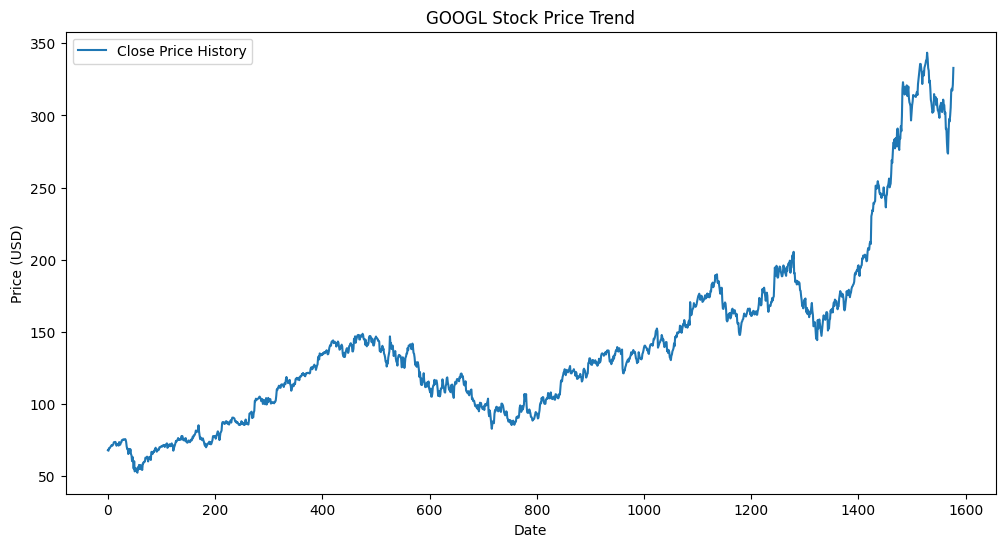

In [34]:

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price History')
plt.title(f'{ticker} Stock Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# 2. Data Preprocessing


In [39]:

data['Date_Ordinal'] = data['Date'].map(pd.Timestamp.toordinal) # AI cannot understand "April 18." We convert the date into a single number

X = data[['Date_Ordinal']] # Feature: The Date
y = data['Close']          # Target: The Price

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training


In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 4. Predictions & Evaluation


In [37]:
y_pred = model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")


Model R2 Score: 0.6677
Mean Squared Error: 1084.80


# 5. Predict a Future Date


In [38]:
future_date = pd.to_datetime('2026-04-20')
future_ordinal = np.array([[future_date.toordinal()]])
predicted_price = model.predict(future_ordinal)

print(f"\n--- Prediction Result ---")
# Use .item() to convert the numpy array value into a single float
print(f"Predicted Price for {ticker} on {future_date.date()}: ${predicted_price.item():.2f}")


--- Prediction Result ---
Predicted Price for GOOGL on 2026-04-20: $230.67
